# Explore here

In [ ]:
import requests       # cargamos la librería que sabe hablar con servidores web (hacer peticiones)
import pandas as pd   # cargamos pandas, que usaremos luego para construir tablas

# Guardamos la dirección a la que vamos a preguntar: temporada 2024, carrera nº1, resultados
url = "https://api.jolpi.ca/ergast/f1/2024/1/results.json"

# Hacemos la petición: "oye servidor, mándame lo que hay en esta URL"
# timeout=30 -> si no contesta en 30 segundos, dejamos de esperar y avisamos de error en vez de quedarnos colgados
response = requests.get(url, timeout=30)

# COMPROBACIÓN DE SEGURIDAD. Si el servidor respondió con un error
# (por ejemplo, error 404 porque la URL está mal, o 500 porque el servidor falló),
# esta línea PARA el programa aquí mismo, con un mensaje claro de qué ha fallado.
# Sin esto, si hubiera un error, el programa seguiría adelante con datos vacíos o rotos,
# y el fallo "de verdad" aparecería 10 líneas más abajo de forma rara y confusa.
response.raise_for_status()

# La respuesta llega como texto con formato JSON. .json() lo convierte en un diccionario
# de Python (como cajones dentro de cajones) para que podamos navegarlo con corchetes ["..."]
data = response.json()

# Vamos abriendo cajones: data -> "MRData" -> "RaceTable" -> "Races"
# "Races" es una LISTA (por eso el [0] al final). Como solo pedimos 1 carrera, solo hay 1 elemento dentro.
carrera = data["MRData"]["RaceTable"]["Races"][0]

# Imprimimos campos sueltos solo para comprobar visualmente que hemos entendido bien la estructura
print("Carrera:", carrera["raceName"])
print("Circuito:", carrera["Circuit"]["circuitName"])
print("Resultado del primer piloto:", carrera["Results"][0])

Carrera: Bahrain Grand Prix
Circuito: Bahrain International Circuit
Resultado del primer piloto: {'number': '1', 'position': '1', 'positionText': '1', 'points': '26', 'Driver': {'driverId': 'max_verstappen', 'permanentNumber': '3', 'code': 'VER', 'url': 'http://en.wikipedia.org/wiki/Max_Verstappen', 'givenName': 'Max', 'familyName': 'Verstappen', 'dateOfBirth': '1997-09-30', 'nationality': 'Dutch'}, 'Constructor': {'constructorId': 'red_bull', 'url': 'https://en.wikipedia.org/wiki/Red_Bull_Racing', 'name': 'Red Bull', 'nationality': 'Austrian'}, 'grid': '1', 'laps': '57', 'status': 'Finished', 'Time': {'millis': '5504742', 'time': '1:31:44.742'}, 'FastestLap': {'rank': '1', 'lap': '39', 'Time': {'time': '1:32.608'}, 'AverageSpeed': {'units': 'kph', 'speed': '210.383'}}}


In [21]:
import requests
import pandas as pd
import numpy as np
import time

url = "https://api.jolpi.ca/ergast/f1/2024/1/results.json"

response = requests.get(url, timeout=30)
response.raise_for_status()

data = response.json()

print(data.keys())
print(data["MRData"].keys())
print(
    data["MRData"]
        ["RaceTable"]
        ["Races"][0]
        .keys()
)


dict_keys(['MRData'])
dict_keys(['xmlns', 'series', 'url', 'limit', 'offset', 'total', 'RaceTable'])
dict_keys(['season', 'round', 'url', 'raceName', 'Circuit', 'date', 'time', 'Results'])


In [22]:
carrera = data["MRData"]["RaceTable"]["Races"][0]

print("Carrera:")
print(carrera["raceName"])

print("Circuito:")
print(carrera["Circuit"]["circuitName"])

print("Primer piloto:")
print(carrera["Results"][0])

Carrera:
Bahrain Grand Prix
Circuito:
Bahrain International Circuit
Primer piloto:
{'number': '1', 'position': '1', 'positionText': '1', 'points': '26', 'Driver': {'driverId': 'max_verstappen', 'permanentNumber': '3', 'code': 'VER', 'url': 'http://en.wikipedia.org/wiki/Max_Verstappen', 'givenName': 'Max', 'familyName': 'Verstappen', 'dateOfBirth': '1997-09-30', 'nationality': 'Dutch'}, 'Constructor': {'constructorId': 'red_bull', 'url': 'https://en.wikipedia.org/wiki/Red_Bull_Racing', 'name': 'Red Bull', 'nationality': 'Austrian'}, 'grid': '1', 'laps': '57', 'status': 'Finished', 'Time': {'millis': '5504742', 'time': '1:31:44.742'}, 'FastestLap': {'rank': '1', 'lap': '39', 'Time': {'time': '1:32.608'}, 'AverageSpeed': {'units': 'kph', 'speed': '210.383'}}}


In [23]:
import requests
import pandas as pd
import time

BASE_URL = "https://api.jolpi.ca/ergast/f1"


def get_json(url, params=None):

    while True:

        response = requests.get(
            url,
            params=params,
            timeout=30
        )

        if response.status_code == 429:
            print("Límite alcanzado. Esperando...")
            time.sleep(20)
            continue

        response.raise_for_status()

        time.sleep(1)

        return response.json()

In [24]:
def numero_de_rondas(season):

    url = f"{BASE_URL}/{season}.json"

    data = get_json(url)

    return int(data["MRData"]["total"])

In [25]:
def obtener_resultados(season, ronda):

    url = f"{BASE_URL}/{season}/{ronda}/results.json"

    data = get_json(url)

    races = data["MRData"]["RaceTable"]["Races"]

    if not races:
        return []

    carrera = races[0]

    filas = []

    for r in carrera["Results"]:

        filas.append({

            "season": season,
            "round": ronda,

            "raceName": carrera["raceName"],
            "raceDate": carrera["date"],

            "circuitId":
                carrera["Circuit"]["circuitId"],

            "circuitName":
                carrera["Circuit"]["circuitName"],

            "country":
                carrera["Circuit"]["Location"]["country"],

            "locality":
                carrera["Circuit"]["Location"]["locality"],

            "driverId":
                r["Driver"]["driverId"],

            "givenName":
                r["Driver"]["givenName"],

            "familyName":
                r["Driver"]["familyName"],

            "driver_nationality":
                r["Driver"]["nationality"],

            "constructorId":
                r["Constructor"]["constructorId"],

            "constructorName":
                r["Constructor"]["name"],

            "constructor_nationality":
                r["Constructor"]["nationality"],

            "number":
                r.get("number"),

            "grid":
                r["grid"],

            "position":
                r["position"],

            "positionText":
                r["positionText"],

            "points":
                r["points"],

            "laps":
                r["laps"],

            "status":
                r["status"],

            "fastest_rank":
                r.get("FastestLap", {})
                 .get("rank"),

            "fastest_lap":
                r.get("FastestLap", {})
                 .get("lap"),

            "fastest_time":
                r.get("FastestLap", {})
                 .get("Time", {})
                 .get("time"),

            "avg_speed":
                r.get("FastestLap", {})
                 .get("AverageSpeed", {})
                 .get("speed")
        })

    return filas

In [26]:
def obtener_clasificacion(season, ronda):

    url = f"{BASE_URL}/{season}/{ronda}/qualifying.json"

    data = get_json(url)

    races = data["MRData"]["RaceTable"]["Races"]

    if not races:
        return []

    filas = []

    for r in races[0]["QualifyingResults"]:

        filas.append({

            "season": season,
            "round": ronda,
            "driverId":
                r["Driver"]["driverId"],

            "quali_position":
                r["position"],

            "Q1":
                r.get("Q1"),

            "Q2":
                r.get("Q2"),

            "Q3":
                r.get("Q3")
        })

    return filas

In [28]:
def obtener_vueltas(season, ronda):

    filas = []

    offset = 0
    limite = 100

    while True:

        url = f"{BASE_URL}/{season}/{ronda}/laps.json"

        data = get_json(
            url,
            params={
                "limit": limite,
                "offset": offset
            }
        )

        races = data["MRData"]["RaceTable"]["Races"]

        if not races:
            break

        for lap in races[0]["Laps"]:

            for t in lap["Timings"]:

                filas.append({

                    "season": season,
                    "round": ronda,
                    "lap": lap["number"],
                    "driverId": t["driverId"],
                    "position_en_vuelta": t["position"],
                    "lap_time": t["time"]

                })

        total = int(data["MRData"]["total"])

        offset += limite

        if offset >= total:
            break

    return filas

In [27]:
def obtener_pitstops(season, ronda):

    url = f"{BASE_URL}/{season}/{ronda}/pitstops.json"

    data = get_json(url)

    races = data["MRData"]["RaceTable"]["Races"]

    if not races:
        return []

    filas = []

    for p in races[0]["PitStops"]:

        filas.append({

            "season": season,
            "round": ronda,
            "driverId": p["driverId"],
            "stop": p["stop"],
            "lap_pit": p["lap"],
            "pit_duration": p["duration"]

        })

    return filas

In [29]:
temporadas = [
    2022,
    2023,
    2024
]

In [31]:
resultados_totales = []
clasificacion_totales = []
pitstops_totales = []
vueltas_totales = []

for season in temporadas:

    n_rondas = numero_de_rondas(season)

    print(f"\n====== TEMPORADA {season} ======")

    for ronda in range(1, n_rondas + 1):

        print(f"Carrera {ronda}/{n_rondas}")

        try:

            resultados = obtener_resultados(
                season,
                ronda
            )

            clasificacion = obtener_clasificacion(
                season,
                ronda
            )

            pits = obtener_pitstops(
                season,
                ronda
            )

            vueltas = obtener_vueltas(
                season,
                ronda
            )

            resultados_totales.extend(
                resultados
            )

            clasificacion_totales.extend(
                clasificacion
            )

            pitstops_totales.extend(
                pits
            )

            vueltas_totales.extend(
                vueltas
            )

            print(
                f"Vueltas acumuladas: {len(vueltas_totales)}"
            )

        except Exception as e:

            print(
                f"Error {season}-{ronda}: {e}"
            )



====== TEMPORADA 2022 ======
Carrera 1/22
Vueltas acumuladas: 1123
Carrera 2/22
Vueltas acumuladas: 1939
Carrera 3/22
Vueltas acumuladas: 2981
Carrera 4/22
Vueltas acumuladas: 4112
Carrera 5/22
Vueltas acumuladas: 5167
Carrera 6/22
Límite alcanzado. Esperando...
Vueltas acumuladas: 6397
Carrera 7/22
Límite alcanzado. Esperando...
Límite alcanzado. Esperando...
Vueltas acumuladas: 7573
Carrera 8/22
Vueltas acumuladas: 8462
Carrera 9/22
Límite alcanzado. Esperando...
Límite alcanzado. Esperando...
Vueltas acumuladas: 9724
Carrera 10/22
Vueltas acumuladas: 10535
Carrera 11/22
Límite alcanzado. Esperando...
Límite alcanzado. Esperando...
Vueltas acumuladas: 11858
Carrera 12/22
Límite alcanzado. Esperando...
Vueltas acumuladas: 12811
Carrera 13/22
Límite alcanzado. Esperando...
Vueltas acumuladas: 14193
Carrera 14/22
Límite alcanzado. Esperando...
Vueltas acumuladas: 14983
Carrera 15/22
Límite alcanzado. Esperando...
Vueltas acumuladas: 16374
Carrera 16/22
Límite alcanzado. Esperando...
Vu

In [32]:
df_resultados = pd.DataFrame(
    resultados_totales
)

df_clasificacion = pd.DataFrame(
    clasificacion_totales
)

df_pits = pd.DataFrame(
    pitstops_totales
)

df_vueltas = pd.DataFrame(
    vueltas_totales
)

In [33]:
print(len(df_resultados))
print(len(df_clasificacion))
print(len(df_pits))
print(len(df_vueltas))

1359
1359
1886
74489


In [34]:
df_resultados.to_csv(
    "resultados.csv",
    index=False
)

df_clasificacion.to_csv(
    "clasificacion.csv",
    index=False
)

df_pits.to_csv(
    "pitstops.csv",
    index=False
)

df_vueltas.to_csv(
    "vueltas.csv",
    index=False
)

In [35]:
df_carrera = df_resultados.merge(
    df_clasificacion,
    on=[
        "season",
        "round",
        "driverId"
    ],
    how="left"
)

In [36]:
df_carrera = df_carrera.merge(
    df_pits,
    on=[
        "season",
        "round",
        "driverId"
    ],
    how="left"
)

In [37]:
df_final = df_vueltas.merge(
    df_carrera,
    on=[
        "season",
        "round",
        "driverId"
    ],
    how="left"
)

In [38]:
print(
    "Filas:",
    len(df_final)
)

print(
    "Variables:",
    len(df_final.columns)
)

df_final.head()

Filas: 109830
Variables: 36


,season,round,lap,driverId,position_en_vuelta,lap_time,raceName,raceDate,circuitId,circuitName,...,fastest_lap,fastest_time,avg_speed,quali_position,Q1,Q2,Q3,stop,lap_pit,pit_duration
0,2022,1,1,leclerc,1,1:39.070,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,51,1:34.570,206.018,1,1:31.471,1:30.932,1:30.558,1,15,25.012
1,2022,1,1,leclerc,1,1:39.070,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,51,1:34.570,206.018,1,1:31.471,1:30.932,1:30.558,2,31,24.527
2,2022,1,1,max_verstappen,2,1:40.236,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,51,1:35.440,204.140,2,1:31.785,1:30.757,1:30.681,1,14,24.897
3,2022,1,1,max_verstappen,2,1:40.236,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,51,1:35.440,204.140,2,1:31.785,1:30.757,1:30.681,2,30,24.937
4,2022,1,1,sainz,3,1:41.006,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,52,1:35.740,203.501,3,1:31.567,1:30.787,1:30.687,1,14,24.666


In [39]:
df_final.to_csv(
    "f1_dataset_final.csv",
    index=False
)

In [5]:
from sqlalchemy import create_engine

engine = create_engine(
    "sqlite:///f1_dataset.db"
)

df_final.to_sql(
    "f1_dataset",
    engine,
    if_exists="replace",
    index=False
)

NameError: name 'df_final' is not defined

In [41]:
pd.read_sql(
    """
    SELECT COUNT(*)
    AS total_filas
    FROM f1_dataset
    """,
    engine
)

,total_filas
0,109830


## EDA

### Antes de empezar con el EDA haremos unas consultas generales con SQL para aportar alfgun valor inicial, es decir preguntas basicas

In [1]:
import pandas as pd

total_data = pd.read_csv("f1_dataset_final.csv")
total_data.head()

,season,round,lap,driverId,position_en_vuelta,lap_time,raceName,raceDate,circuitId,circuitName,...,fastest_lap,fastest_time,avg_speed,quali_position,Q1,Q2,Q3,stop,lap_pit,pit_duration
0,2022,1,1,leclerc,1,1:39.070,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,51.0,1:34.570,206.018,1,1:31.471,1:30.932,1:30.558,1.0,15.0,25.012
1,2022,1,1,leclerc,1,1:39.070,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,51.0,1:34.570,206.018,1,1:31.471,1:30.932,1:30.558,2.0,31.0,24.527
2,2022,1,1,max_verstappen,2,1:40.236,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,51.0,1:35.440,204.140,2,1:31.785,1:30.757,1:30.681,1.0,14.0,24.897
3,2022,1,1,max_verstappen,2,1:40.236,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,51.0,1:35.440,204.140,2,1:31.785,1:30.757,1:30.681,2.0,30.0,24.937
4,2022,1,1,sainz,3,1:41.006,Bahrain Grand Prix,2022-03-20,bahrain,Bahrain International Circuit,...,52.0,1:35.740,203.501,3,1:31.567,1:30.787,1:30.687,1.0,14.0,24.666


In [2]:
from sqlalchemy import create_engine
import pandas as pd

# Apuntamos al mismo archivo .db que ya generaste en el notebook de extracción
engine = create_engine("sqlite:///f1_dataset.db")

# Consulta 1: posición media de cada constructor
pd.read_sql("""
    SELECT constructorName,
           AVG(CAST(position AS FLOAT)) AS posicion_media,
           COUNT(DISTINCT raceName) AS carreras
    FROM f1_dataset
    WHERE position GLOB '[0-9]*'
    GROUP BY constructorName
    ORDER BY posicion_media ASC
""", engine)

,constructorName,posicion_media,carreras
0,Red Bull,4.570629,25
1,Ferrari,5.346768,25
2,Mercedes,5.978226,25
3,McLaren,7.887540,25
4,Aston Martin,10.498762,25
5,Alpine F1 Team,10.556249,25
6,RB F1 Team,12.633924,24
7,Alfa Romeo,13.126566,24
8,AlphaTauri,13.339452,24
9,Haas F1 Team,13.702177,25


### Aqui podemos observar 

### Empezaremos con el EDA

In [3]:
# Obtener las dimensiones
total_data.shape

(109830, 36)

Podemos observar que el dataset contiene 109830 filas
y 36 columnas, lo que indica que disponemos de
información de varias temporadas y carreras.

In [4]:
# Obtener información sobre tipos de datos y valores no nulos
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 109830 entries, 0 to 109829
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   season                   109830 non-null  int64  
 1   round                    109830 non-null  int64  
 2   lap                      109830 non-null  int64  
 3   driverId                 109830 non-null  str    
 4   position_en_vuelta       109830 non-null  int64  
 5   lap_time                 109830 non-null  str    
 6   raceName                 109830 non-null  str    
 7   raceDate                 109830 non-null  str    
 8   circuitId                109830 non-null  str    
 9   circuitName              109830 non-null  str    
 10  country                  109830 non-null  str    
 11  locality                 109830 non-null  str    
 12  givenName                109830 non-null  str    
 13  familyName               109830 non-null  str    
 14  driver_national

Podemos observar que existen variables numéricas
y categóricas. También podemos identificar si
existen valores nulos que deberán tratarse
posteriormente.

In [5]:
total_data.duplicated().sum()

np.int64(0)

Podemos observar que existen 0 registros duplicados.
En caso de haberlos, se eliminarán para evitar
introducir ruido en el análisis.

In [6]:
total_data.isnull().sum()

season                         0
round                          0
lap                            0
driverId                       0
position_en_vuelta             0
lap_time                       0
raceName                       0
raceDate                       0
circuitId                      0
circuitName                    0
country                        0
locality                       0
givenName                      0
familyName                     0
driver_nationality             0
constructorId                  0
constructorName                0
constructor_nationality        0
number                         0
grid                           0
position                       0
positionText                   0
points                         0
laps                           0
status                         0
fastest_rank                  99
fastest_lap                   99
fastest_time                  99
avg_speed                   2903
quali_position                 0
Q1        

Podemos observar que las columnas fastest_rank,fastest_lap,fastest_time,avg_speed,Q1,Q2,Q3, stop, lap_pit, pit_duration presentan
valores nulos. Especialmente las relacionadas con tiempos, velocidad o vueltas. Estos valores pueden deberse a abandonos, descalificaciones o datos no disponibles en determinadas carreras.

In [7]:
total_data.describe()

,season,round,lap,position_en_vuelta,number,grid,position,points,laps,fastest_rank,fastest_lap,avg_speed,quali_position,stop,lap_pit
count,109830.000000,109830.000000,109830.000000,109830.000000,109830.000000,109830.000000,109830.000000,109830.000000,109830.000000,109731.000000,109731.000000,106927.000000,109830.000000,108847.000000,108847.000000
mean,2023.033506,11.954439,30.514705,10.122471,26.789402,10.373678,10.061358,5.258691,60.004826,9.778549,47.767404,209.369813,10.523199,1.348857,21.656233
std,0.814774,6.430424,18.366004,5.489121,22.545920,5.845550,5.455709,7.235570,10.653776,5.505019,12.775016,20.281404,5.777488,0.528736,13.258384
min,2022.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000,128.135000,1.000000,1.000000,1.000000
25%,2022.000000,7.000000,15.000000,5.000000,11.000000,5.000000,5.000000,0.000000,53.000000,5.000000,42.000000,197.444000,6.000000,1.000000,12.000000
50%,2023.000000,12.000000,30.000000,10.000000,20.000000,10.000000,10.000000,1.000000,58.000000,10.000000,49.000000,208.753000,11.000000,1.000000,20.000000
75%,2024.000000,17.000000,45.000000,15.000000,43.000000,16.000000,15.000000,10.000000,70.000000,14.000000,56.000000,224.752000,16.000000,2.000000,31.000000
max,2024.000000,24.000000,78.000000,20.000000,81.000000,20.000000,20.000000,26.000000,78.000000,20.000000,77.000000,256.100000,20.000000,4.000000,70.000000


Podemos observar las principales medidas estadísticas de las
variables numéricas: media, mediana, desviación típica y valores
máximos y mínimos. Esto permite detectar posibles valores atípicos y conocer mejor cómo están distribuidos los datos.

# Análisis univariante

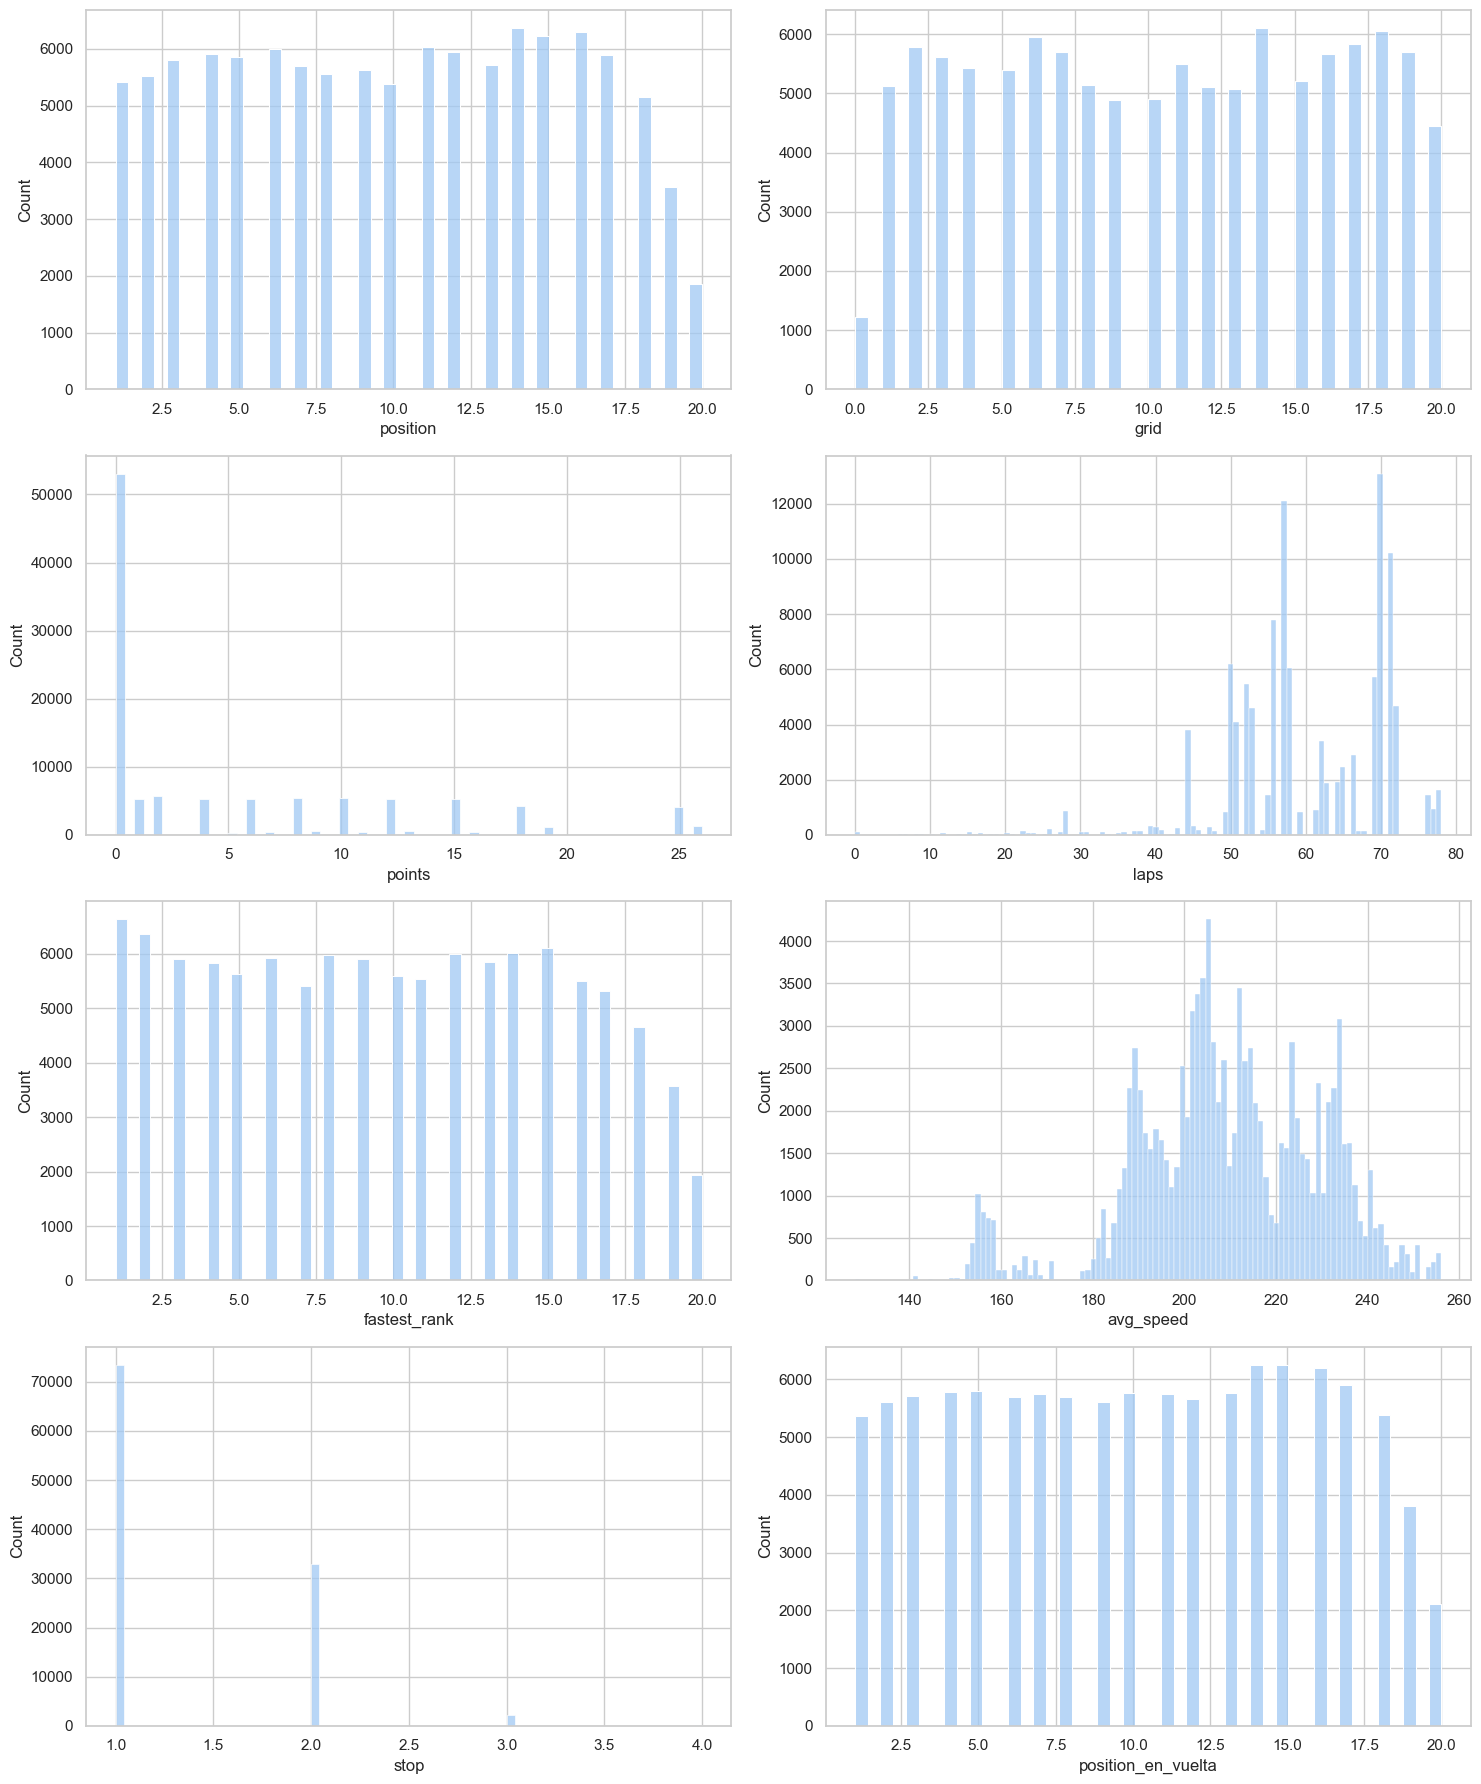

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")

fig, axis = plt.subplots(4, 2, figsize=(15,18))

# Position
sns.histplot(ax=axis[0,0], data=total_data, x="position")

# Grid
sns.histplot(ax=axis[0,1], data=total_data, x="grid")

# Points
sns.histplot(ax=axis[1,0], data=total_data, x="points")

# Laps
sns.histplot(ax=axis[1,1], data=total_data, x="laps")

# Fastest Rank
sns.histplot(ax=axis[2,0], data=total_data, x="fastest_rank")

# Avg Speed
sns.histplot(ax=axis[2,1], data=total_data, x="avg_speed")

# Stop
sns.histplot(ax=axis[3,0], data=total_data, x="stop")

# Position en vuelta
sns.histplot(ax=axis[3,1], data=total_data, x="position_en_vuelta")

plt.tight_layout()
plt.show()

1. Position (arriba izquierda)

  Podemos observar que la distribución de las posiciones finales
  es relativamente uniforme entre las posiciones 1 y 18.
  Las posiciones 19 y 20 aparecen con menor frecuencia, probablemente
  debido a abandonos, descalificaciones o al menor número de pilotos
  que terminan en estas posiciones.

2. Grid (arriba derecha)

  Podemos observar que la posición de salida está bastante equilibrada
  entre todos los pilotos, ya que a lo largo de las distintas carreras
  los pilotos han ocupado prácticamente todas las posiciones de la parrilla.

3. Points (segunda fila izquierda)
  
  Podemos observar que la mayoría de los registros corresponden
  a pilotos que no consiguen puntos. Esto se debe a que únicamente
  los diez primeros clasificados puntúan en cada carrera.

  Las puntuaciones altas aparecen con mucha menor frecuencia,
  ya que están reservadas a los pilotos que terminan en las
  primeras posiciones.

4. Laps (segunda fila derecha)

 Podemos observar varios picos en la distribución del número de
 vueltas. Esto se debe a que cada circuito del campeonato tiene
 una longitud diferente y, por tanto, las carreras se disputan
 con un número distinto de vueltas. 

5. Fastest Rank (tercera fila izquierda)

 Podemos observar una distribución relativamente uniforme de la
 clasificación de la vuelta rápida. Esto indica que a lo largo de
 las temporadas analizadas muchos pilotos han ocupado diferentes
 posiciones en cuanto al rendimiento de la vuelta rápida.

6. Avg Speed (tercera fila derecha)

 Podemos observar que la velocidad media sigue una distribución
 aproximadamente normal, concentrándose principalmente entre los
 190 y los 230 km/h.

 Las diferencias observadas se deben a las características de cada
 circuito, ya que algunos son más rápidos y otros más técnicos.

7. Stop (abajo izquierda)

 Podemos observar que la mayoría de los pilotos realizan una única
 parada en boxes durante la carrera.

 Las estrategias de dos o más paradas son mucho menos frecuentes y
 suelen depender de factores como el desgaste de neumáticos,
 incidentes o condiciones meteorológicas.

8. Position en vuelta (abajo derecha)

 Podemos observar que las posiciones de los pilotos durante las
 vueltas se encuentran relativamente repartidas entre las veinte
 posiciones disponibles, lo que refleja los continuos cambios de
 posición que se producen durante las carreras.






9. Conclusion


 En general, las variables analizadas muestran distribuciones
 coherentes con el funcionamiento de la Fórmula 1.

 Se observa que la mayoría de pilotos no consiguen puntos,
 que las estrategias de una parada son las más habituales y
 que variables como la posición de salida o la velocidad media
 podrían tener una gran influencia sobre la posición final,
 siendo candidatas importantes para el futuro modelo predictivo.

# Diagrama de cajas  (outliers)

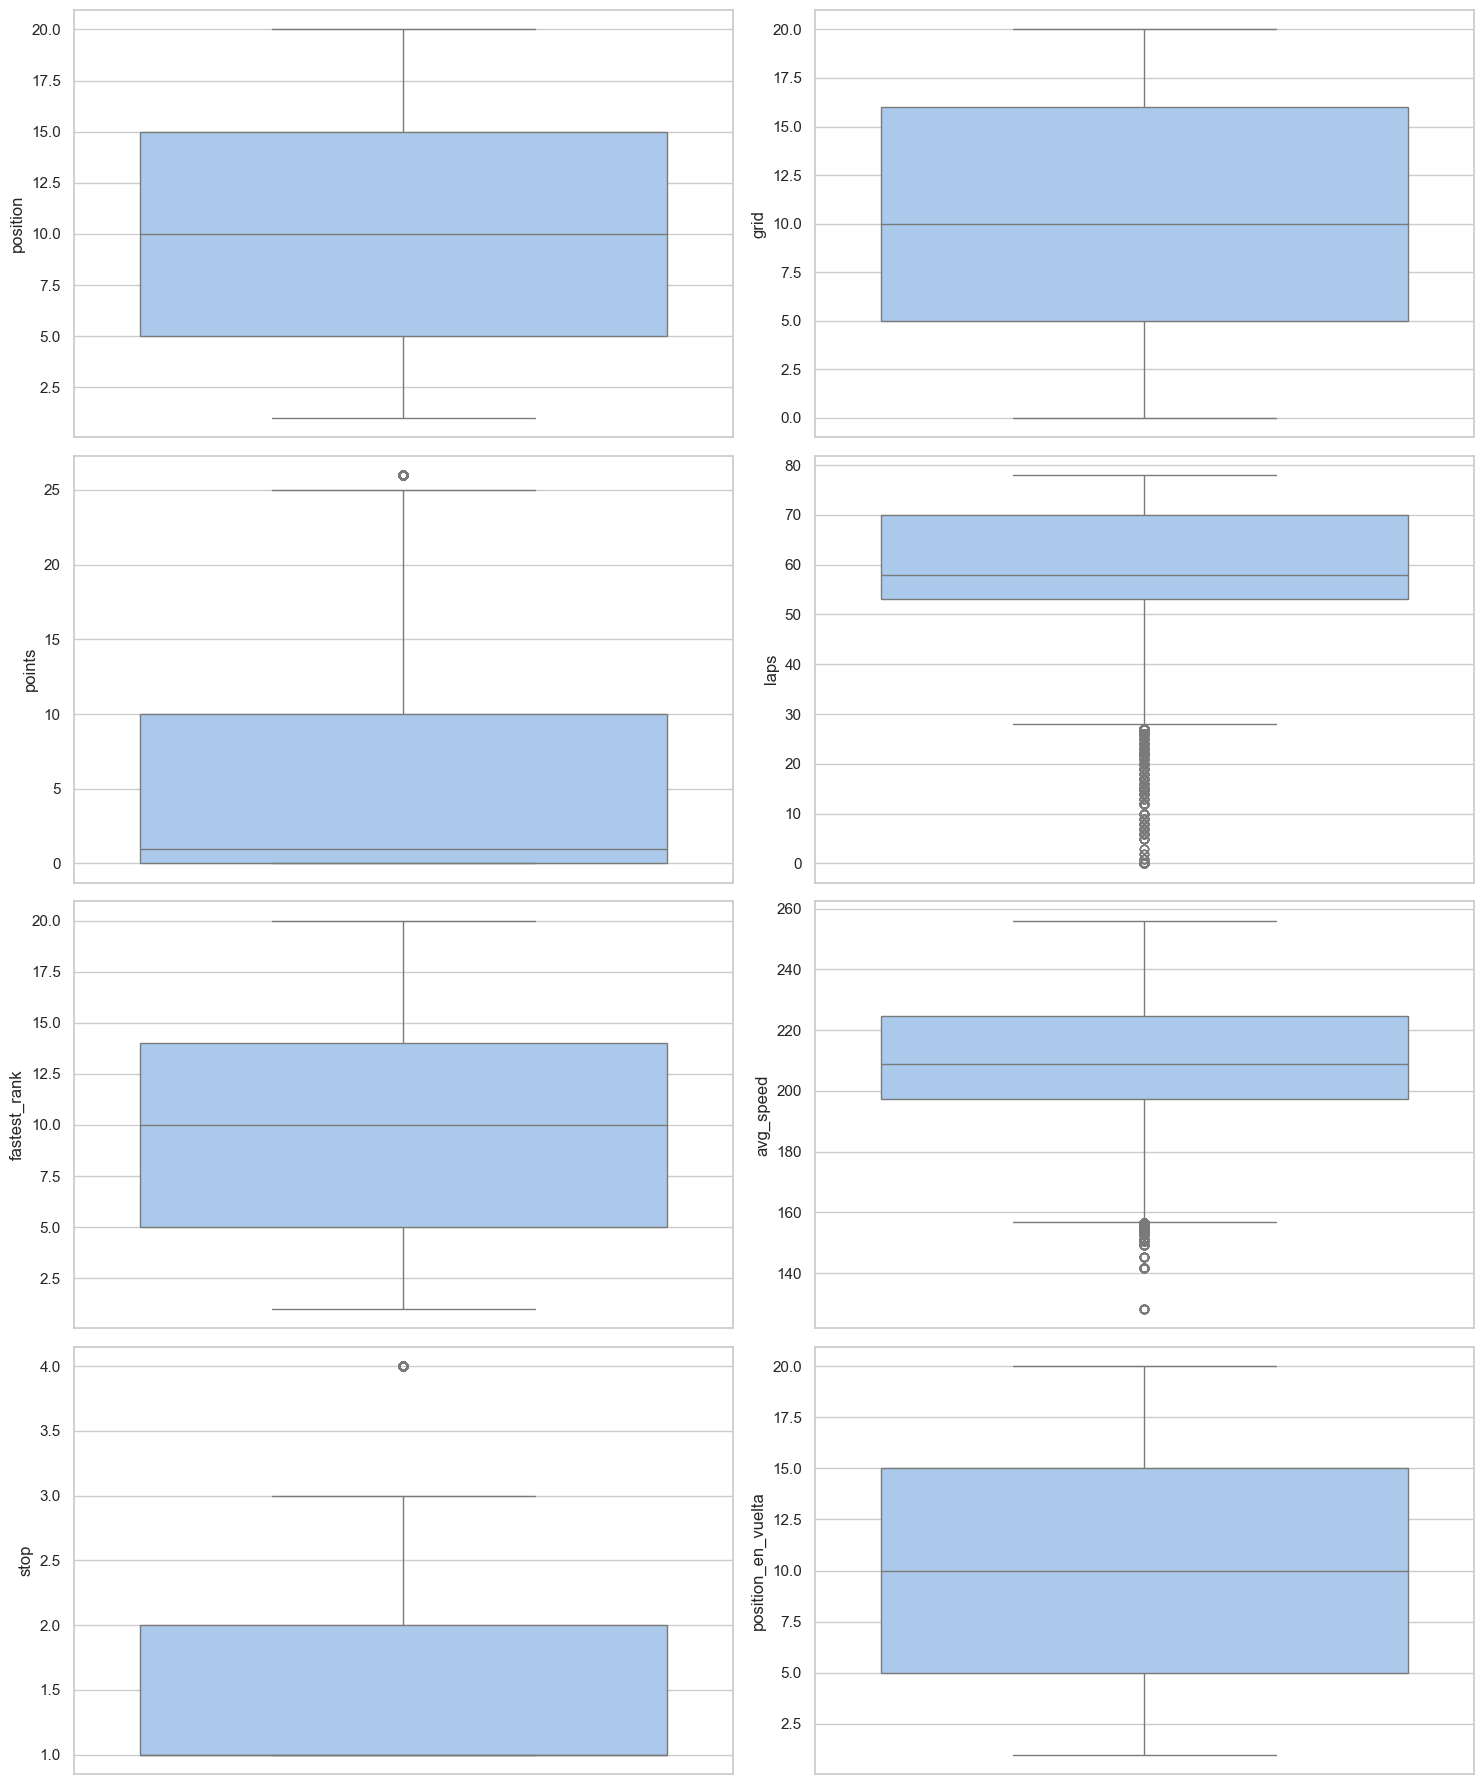

In [9]:
fig, axis = plt.subplots(4,2, figsize=(15,18))

sns.boxplot(ax=axis[0,0], data=total_data, y="position")
sns.boxplot(ax=axis[0,1], data=total_data, y="grid")
sns.boxplot(ax=axis[1,0], data=total_data, y="points")
sns.boxplot(ax=axis[1,1], data=total_data, y="laps")
sns.boxplot(ax=axis[2,0], data=total_data, y="fastest_rank")
sns.boxplot(ax=axis[2,1], data=total_data, y="avg_speed")
sns.boxplot(ax=axis[3,0], data=total_data, y="stop")
sns.boxplot(ax=axis[3,1], data=total_data, y="position_en_vuelta")

plt.tight_layout()
plt.show()

# Análisis numérico-numérico

Como queremos predecir position, todas las comparaciones deben hacerse contra position.

Position vs Grid

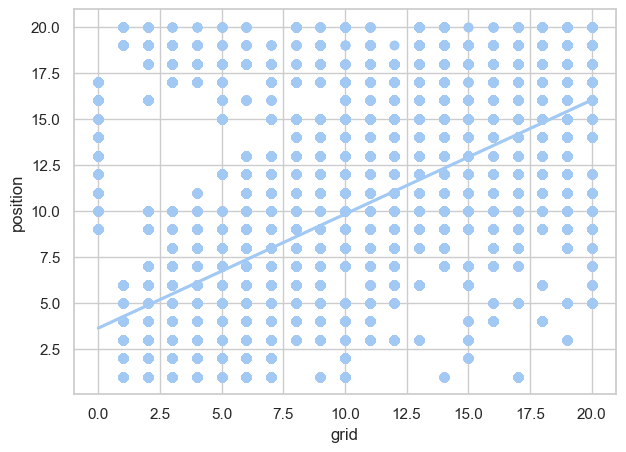

In [10]:
fig, ax = plt.subplots(figsize=(7,5))

sns.regplot(
    data=total_data,
    x="grid",
    y="position"
)

plt.show()

Position vs Points

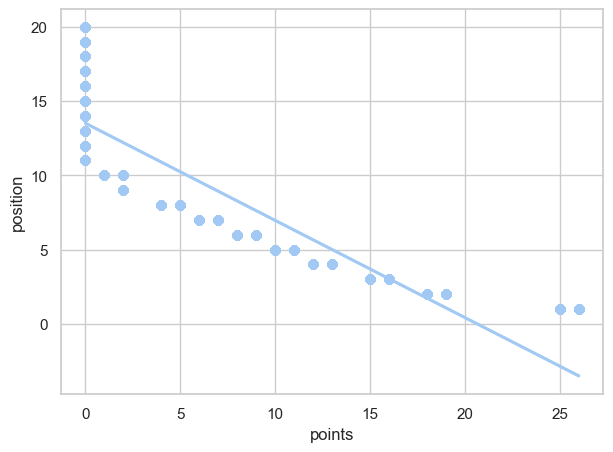

In [11]:
fig, ax = plt.subplots(figsize=(7,5))

sns.regplot(
    data=total_data,
    x="points",
    y="position"
)

plt.show()

Position vs Avg Speed

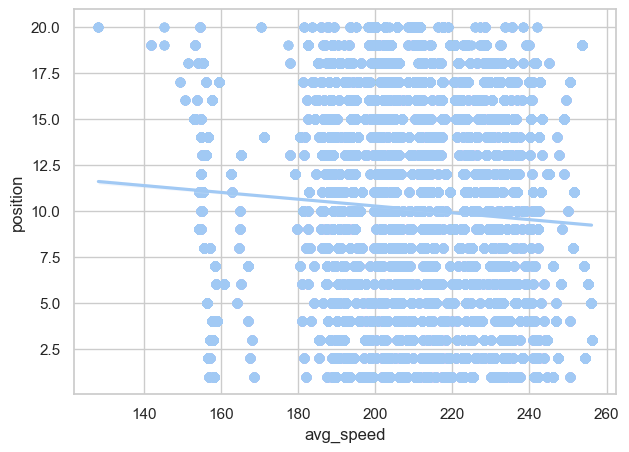

In [12]:
fig, ax = plt.subplots(figsize=(7,5))

sns.regplot(
    data=total_data,
    x="avg_speed",
    y="position"
)

plt.show()

Position vs Fastest Rank

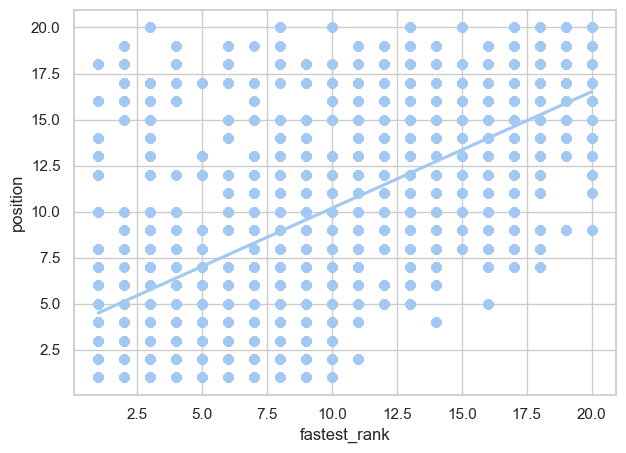

In [13]:
fig, ax = plt.subplots(figsize=(7,5))

sns.regplot(
    data=total_data,
    x="fastest_rank",
    y="position"
)

plt.show()

Position vs Position en Vuelta

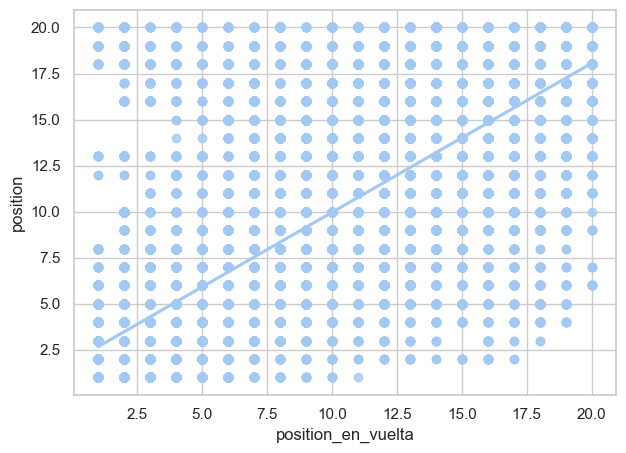

In [14]:
fig, ax = plt.subplots(figsize=(7,5))

sns.regplot(
    data=total_data,
    x="position_en_vuelta",
    y="position"
)

plt.show()

# Matriz de correlación

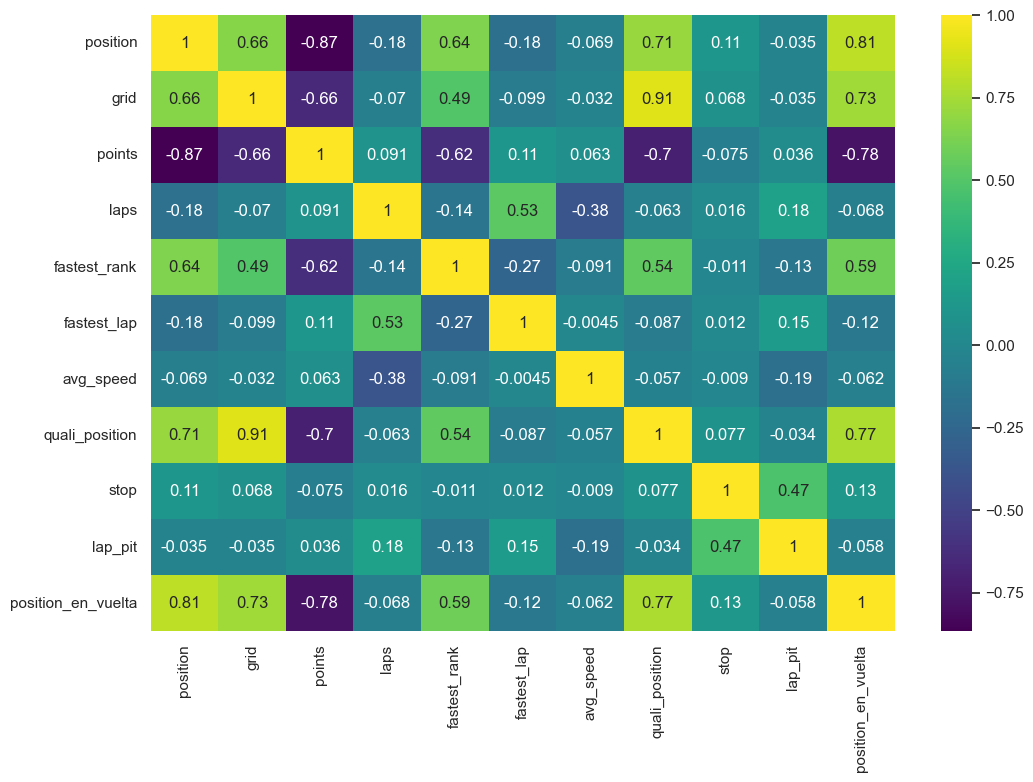

In [15]:
cols = [
    "position",
    "grid",
    "points",
    "laps",
    "fastest_rank",
    "fastest_lap",
    "avg_speed",
    "quali_position",
    "stop",
    "lap_pit",
    "position_en_vuelta"
]

plt.figure(figsize=(12,8))

sns.heatmap(
    total_data[cols].corr(),
    annot=True,
    cmap="viridis"
)

plt.show()

# Análisis categórico-categórico

Posición por escudería

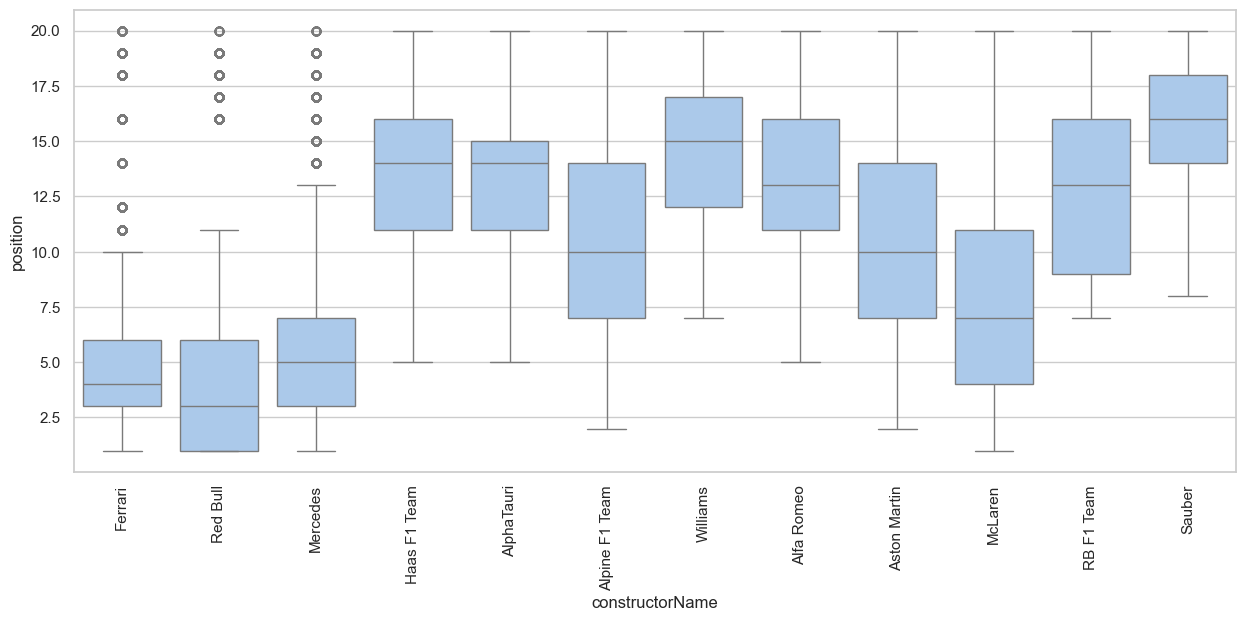

In [16]:
plt.figure(figsize=(15,6))

sns.boxplot(
    data=total_data,
    x="constructorName",
    y="position"
)

plt.xticks(rotation=90)
plt.show()

Posición por temporada

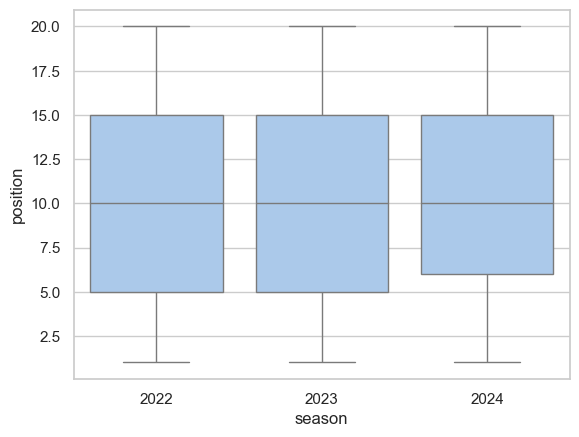

In [17]:
sns.boxplot(
    data=total_data,
    x="season",
    y="position"
)

plt.show()

# Pairplot

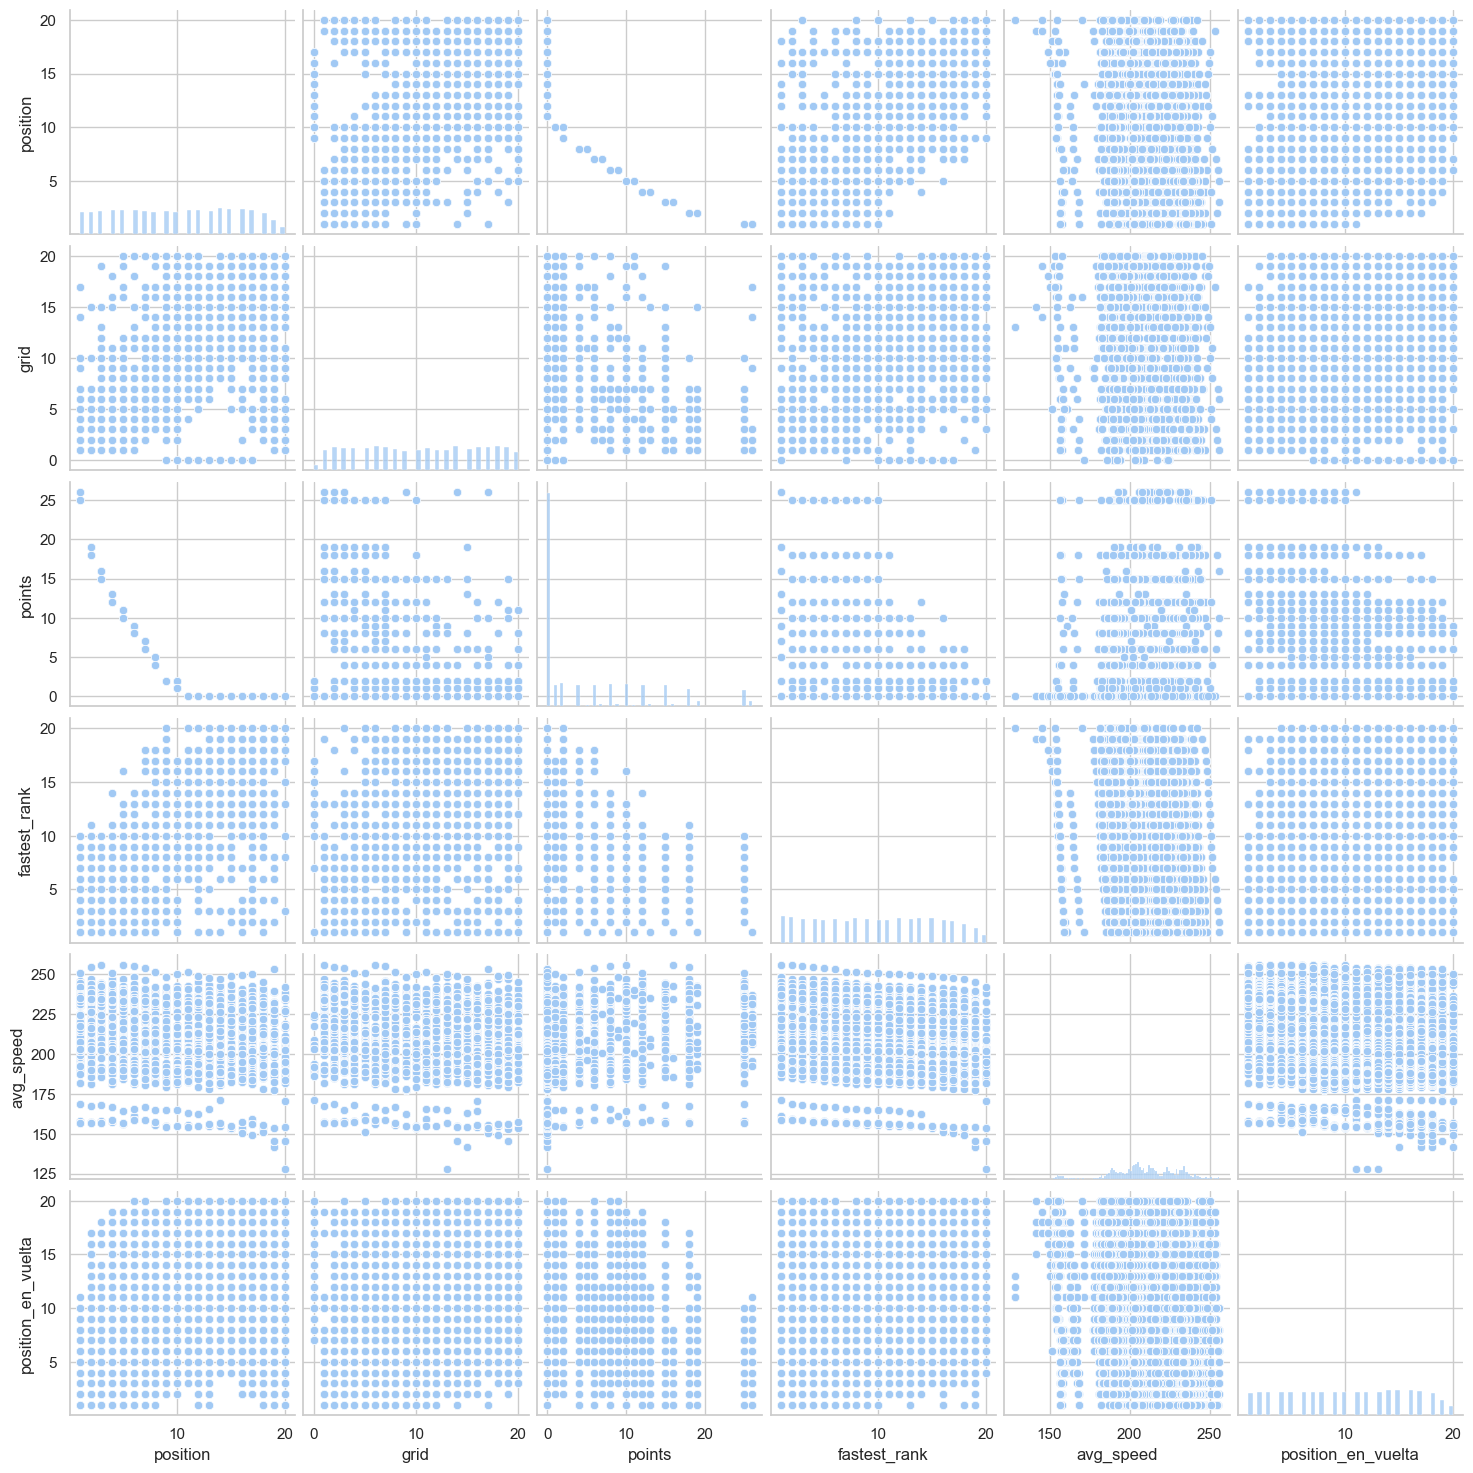

In [18]:
sns.pairplot(
    total_data[
        [
            "position",
            "grid",
            "points",
            "fastest_rank",
            "avg_speed",
            "position_en_vuelta"
        ]
    ]
)

# Ver que variables tienen outliers

In [19]:
variables_numericas = [
    "position",
    "grid",
    "points",
    "laps",
    "fastest_rank",
    "fastest_lap",
    "avg_speed",
    "quali_position",
    "stop",
    "lap_pit",
    "position_en_vuelta"
]

for col in variables_numericas:

    stats = total_data[col].describe()

    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr

    outliers = total_data[
        (total_data[col] < lower_limit) |
        (total_data[col] > upper_limit)
    ]

    porcentaje = len(outliers) / len(total_data) * 100

    print(f"\n{col.upper()}")
    print(f"IQR: {round(iqr,2)}")
    print(f"Límite inferior: {round(lower_limit,2)}")
    print(f"Límite superior: {round(upper_limit,2)}")
    print(f"Outliers: {len(outliers)} ({round(porcentaje,2)}%)")


POSITION
IQR: 10.0
Límite inferior: -10.0
Límite superior: 30.0
Outliers: 0 (0.0%)

GRID
IQR: 11.0
Límite inferior: -11.5
Límite superior: 32.5
Outliers: 0 (0.0%)

POINTS
IQR: 10.0
Límite inferior: -15.0
Límite superior: 25.0
Outliers: 1330 (1.21%)

LAPS
IQR: 17.0
Límite inferior: 27.5
Límite superior: 95.5
Outliers: 1364 (1.24%)

FASTEST_RANK
IQR: 9.0
Límite inferior: -8.5
Límite superior: 27.5
Outliers: 0 (0.0%)

FASTEST_LAP
IQR: 14.0
Límite inferior: 21.0
Límite superior: 77.0
Outliers: 4727 (4.3%)

AVG_SPEED
IQR: 27.31
Límite inferior: 156.48
Límite superior: 265.71
Outliers: 2309 (2.1%)

QUALI_POSITION
IQR: 10.0
Límite inferior: -9.0
Límite superior: 31.0
Outliers: 0 (0.0%)

STOP
IQR: 1.0
Límite inferior: -0.5
Límite superior: 3.5
Outliers: 221 (0.2%)

LAP_PIT
IQR: 19.0
Límite inferior: -16.5
Límite superior: 59.5
Outliers: 358 (0.33%)

POSITION_EN_VUELTA
IQR: 10.0
Límite inferior: -10.0
Límite superior: 30.0
Outliers: 0 (0.0%)


 Tras analizar los posibles valores atípicos, se concluye
 que todos ellos representan situaciones reales de la
 competición (diferencias entre circuitos, estrategias,
 abandonos o condiciones de carrera).

 Por este motivo se decide no aplicar ningún tratamiento
 de outliers y conservar toda la información disponible
 para el posterior modelo predictivo.

# Seleccion de caracteristicas

In [31]:
variables_importantes = [
    "season",
    "round",
    "driverId",
    "constructorId",
    "constructorName",
    "driver_nationality",
    "constructor_nationality",
    "circuitId",
    "circuitName",
    "country",
    "grid",
    "quali_position",
    "avg_speed",
    "fastest_rank",
    "fastest_lap",
    "laps",
    "stop",
    "lap_pit",
    "number"
]

X = total_data[variables_importantes].copy()

y = total_data["position"]

 Se han seleccionado las variables que, tras el análisis
 exploratorio, presentan una mayor relación con la posición
 final del piloto.

 Las variables elegidas aportan información sobre:
 - el piloto,
 - la escudería,
 - el circuito,
 - la clasificación,
 - y el rendimiento durante la carrera.

 Se han descartado variables redundantes o con un elevado
 número de valores nulos, ya que su aportación al modelo
 sería limitada.

# Imputar los nulos

In [32]:
X["avg_speed"] = X["avg_speed"].fillna(
    X["avg_speed"].median()
)

X["fastest_rank"] = X["fastest_rank"].fillna(
    X["fastest_rank"].median()
)

X["fastest_lap"] = X["fastest_lap"].fillna(
    X["fastest_lap"].median()
)

X["stop"] = X["stop"].fillna(
    X["stop"].median()
)

X["lap_pit"] = X["lap_pit"].fillna(
    X["lap_pit"].median()
)

X.isnull().sum()

season                     0
round                      0
driverId                   0
constructorId              0
constructorName            0
driver_nationality         0
constructor_nationality    0
circuitId                  0
circuitName                0
country                    0
grid                       0
quali_position             0
avg_speed                  0
fastest_rank               0
fastest_lap                0
laps                       0
stop                       0
lap_pit                    0
number                     0
dtype: int64

# Convertir variables categóricas

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columnas_categoricas = [
    "driverId",
    "constructorId",
    "constructorName",
    "driver_nationality",
    "constructor_nationality",
    "circuitId",
    "circuitName",
    "country"
]

for col in columnas_categoricas:
    X[col] = le.fit_transform(X[col])


X.info()


<class 'pandas.DataFrame'>
RangeIndex: 109830 entries, 0 to 109829
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   season                   109830 non-null  int64  
 1   round                    109830 non-null  int64  
 2   driverId                 109830 non-null  int64  
 3   constructorId            109830 non-null  int64  
 4   constructorName          109830 non-null  int64  
 5   driver_nationality       109830 non-null  int64  
 6   constructor_nationality  109830 non-null  int64  
 7   circuitId                109830 non-null  int64  
 8   circuitName              109830 non-null  int64  
 9   country                  109830 non-null  int64  
 10  grid                     109830 non-null  int64  
 11  quali_position           109830 non-null  int64  
 12  avg_speed                109830 non-null  float64
 13  fastest_rank             109830 non-null  float64
 14  fastest_lap    

# Dividimos en Train y Test

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Primer modelo: Random forest

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf)**0.5)
print("R2:", r2_score(y_test, y_pred_rf))

MAE: 0.0010138395702449243
MSE: 0.00638573477192024
RMSE: 0.07991079258723592
R2: 0.9997862661810957


# Segundo modelo: Gradient  Boosting

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("RMSE:", mean_squared_error(y_test, y_pred_gb)**0.5)
print("R2:", r2_score(y_test, y_pred_gb))

MAE: 1.822262029558532
MSE: 5.755658897970902
RMSE: 2.399095433277072
R2: 0.8073551438459876


# Tercer modelo: XGBoost

In [37]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", mean_squared_error(y_test, y_pred_xgb)**0.5)
print("R2:", r2_score(y_test, y_pred_xgb))

MAE: 0.43439221382141113
MSE: 0.3490939140319824
RMSE: 0.5908416996387293
R2: 0.9883156418800354


In [39]:
resultados = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "R2": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_xgb)
    ],
    "RMSE": [
        mean_squared_error(y_test, y_pred_rf)**0.5,
        mean_squared_error(y_test, y_pred_gb)**0.5,
        mean_squared_error(y_test, y_pred_xgb)**0.5
    ]
})

resultados.sort_values(
    by="R2",
    ascending=False
)

,Modelo,R2,RMSE
0,Random Forest,0.999786,0.079911
2,XGBoost,0.988316,0.590842
1,Gradient Boosting,0.807355,2.399095


In [40]:
import pandas as pd

importancias = pd.Series(rf.feature_importances_, index=X_train.columns)
importancias.sort_values(ascending=False)

quali_position             0.482667
fastest_rank               0.164075
laps                       0.040053
fastest_lap                0.038650
avg_speed                  0.035054
grid                       0.031901
number                     0.023359
round                      0.022435
country                    0.020952
circuitName                0.019950
constructorId              0.018504
constructorName            0.018480
circuitId                  0.016651
season                     0.015473
driverId                   0.014899
constructor_nationality    0.013574
lap_pit                    0.012565
driver_nationality         0.010605
stop                       0.000151
dtype: float64